# MORPHOLOGICAL OPERATIONS ! ( GRP 4)
## Smruti Pawaskar & Ashay Berde


## Ground Truth (Software)
We will first see the ground truth for our image

In [97]:
import cv2  # Computer vision library for image processing
import numpy as np  # Library for numerical operations
import matplotlib.pyplot as plt  # Plotting library for visualization


# Loading image
img = cv2.imread('tiger.jpg', cv2.IMREAD_GRAYSCALE)

# Checking if image is loaded properly
if img is None:
    print("Error: Image cannot be loaded. Please check the path.")
    exit()

In [98]:
# Defining the kernel size
kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), np.uint8)

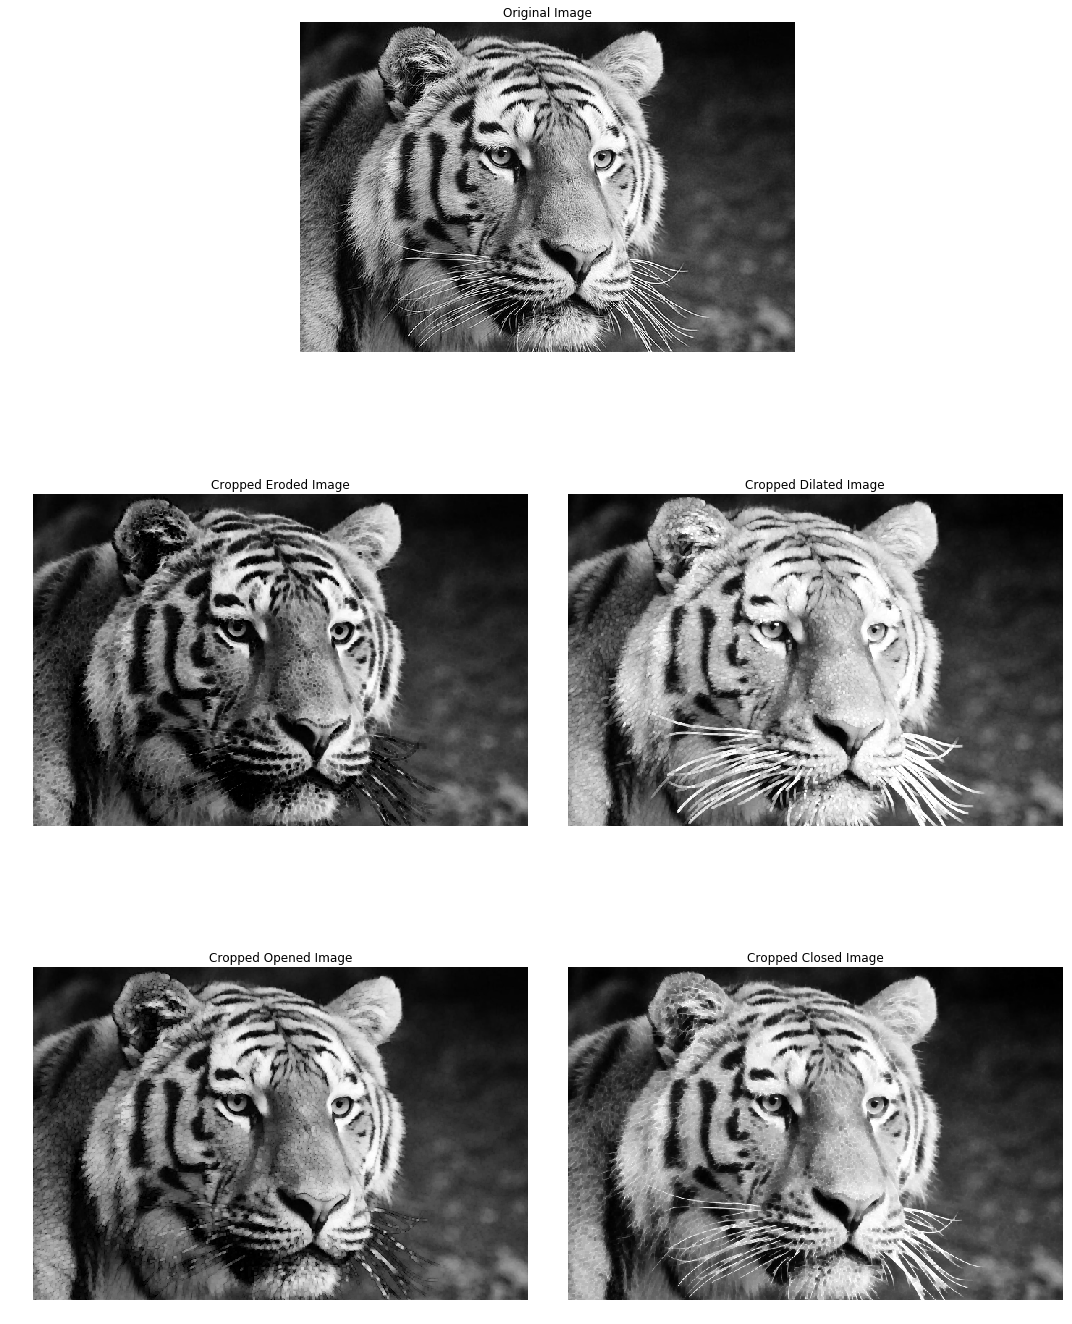

In [99]:
import cv2
import matplotlib.pyplot as plt

# Create a figure
fig = plt.figure(figsize=(15, 20))  # Adjust the size as needed

# Set up the axes for the central original image
ax_original = plt.subplot2grid((3, 4), (0, 1), colspan=2)
ax_original.imshow(img, cmap='gray')
ax_original.set_title('Original Image')
ax_original.axis('off')

# Eroded Image
ax_eroded = plt.subplot2grid((3, 4), (1, 0), colspan=2)
eroded_img = cv2.erode(img, kernel, iterations=1)
cropped_eroded_img = eroded_img[:460, :684] 
ax_eroded.imshow(cropped_eroded_img, cmap='gray')
ax_eroded.set_title('Cropped Eroded Image')
ax_eroded.axis('off')

# Dilated Image
ax_dilated = plt.subplot2grid((3, 4), (1, 2), colspan=2)
dilated_img = cv2.dilate(img, kernel, iterations=1)
cropped_dilated_img = dilated_img[:460, :684]
ax_dilated.imshow(cropped_dilated_img, cmap='gray')
ax_dilated.set_title('Cropped Dilated Image')
ax_dilated.axis('off')

# Opened Image : Erosion followed by Dilation
ax_opened = plt.subplot2grid((3, 4), (2, 0), colspan=2)
opened_img = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
cropped_opened_img = opened_img[:460, :684]
ax_opened.imshow(cropped_opened_img, cmap='gray')
ax_opened.set_title('Cropped Opened Image')
ax_opened.axis('off')

# Closed Image: Dilation followed by Erosion
ax_closed = plt.subplot2grid((3, 4), (2, 2), colspan=2)
closed_img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
cropped_closed_img = closed_img[:460, :684]
ax_closed.imshow(cropped_closed_img, cmap='gray')
ax_closed.set_title('Cropped Closed Image')
ax_closed.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


## Hardware Part 

## DMA to stream interfaces

This overlay consists of two DMAs and an filter (it has input and output AXI stream interfaces). 

* The first DMA with read channel enabled is connected from DDR to IP input stream (reading from DDR, and sending to AXI stream).
* The second DMA has a write channel enabled and is connected to IP output stream to DDR (receiving from AXI stream, and writing to DDR memory).


## Downloading overlay

In [121]:
from pynq import Overlay # Import the Overlay module from the PYNQ library

In [122]:
overlay = Overlay("./bitstream/final_prj.bit") #our customised bitstream from fpga is loaded

In [123]:
overlay?

In [124]:
switch= overlay.switch_0
switch?

In [125]:
switch.write(0x08,0)
# switching between different morphological operations
# insert 0 gives Erosion, 1 gives Dilation, 2 gives Opening, 3 gives Closing

We can check the IPs in this overlay. Notice the DMAs *axi_dma_from_pl_to_ps* and *axi_dma_from_pl_to_ps*.

In [126]:
overlay.ip_dict

{'axi_dma_from_pl_to_ps': {'addr_range': 65536,
  'device': <pynq.pl_server.device.XlnkDevice at 0xa571f6b0>,
  'driver': pynq.lib.dma.DMA,
  'fullpath': 'axi_dma_from_pl_to_ps',
  'gpio': {},
  'interrupts': {},
  'mem_id': 'S_AXI_LITE',
  'parameters': {'C_BASEADDR': '0x40400000',
   'C_DLYTMR_RESOLUTION': '125',
   'C_ENABLE_MULTI_CHANNEL': '0',
   'C_FAMILY': 'zynq',
   'C_HIGHADDR': '0x4040FFFF',
   'C_INCLUDE_MM2S': '0',
   'C_INCLUDE_MM2S_DRE': '0',
   'C_INCLUDE_MM2S_SF': '1',
   'C_INCLUDE_S2MM': '1',
   'C_INCLUDE_S2MM_DRE': '0',
   'C_INCLUDE_S2MM_SF': '1',
   'C_INCLUDE_SG': '0',
   'C_INCREASE_THROUGHPUT': '0',
   'C_MICRO_DMA': '0',
   'C_MM2S_BURST_SIZE': '16',
   'C_M_AXIS_MM2S_CNTRL_TDATA_WIDTH': '32',
   'C_M_AXIS_MM2S_TDATA_WIDTH': '32',
   'C_M_AXI_MM2S_ADDR_WIDTH': '32',
   'C_M_AXI_MM2S_DATA_WIDTH': '32',
   'C_M_AXI_S2MM_ADDR_WIDTH': '32',
   'C_M_AXI_S2MM_DATA_WIDTH': '32',
   'C_M_AXI_SG_ADDR_WIDTH': '32',
   'C_M_AXI_SG_DATA_WIDTH': '32',
   'C_NUM_MM2S_CHANNE

## Creating DMA instances

In [127]:
import pynq.lib.dma

dma_send = overlay.axi_dma_from_ps_to_pl
dma_recv = overlay.axi_dma_from_pl_to_ps

## Reading DMA
We will read the data from memory, and write to FIFO in the following cells.

The first step is to allocate the buffer. pynq.allocate will be used to allocate the buffer, and NumPy will be used to specify the type of the buffer. 

In [128]:
from pynq import allocate
import numpy as np

data_size = 321785
input_buffer = allocate(shape=(data_size,), dtype=np.uint32)

In [129]:
from PIL import Image  # Import the Image class from the PIL (Pillow) library for image manipulation
import matplotlib.pyplot as plt  # Import pyplot module from matplotlib for plotting
import numpy as np  # Import numpy for numerical operations on arrays

%matplotlib inline 

image_path = "tiger.jpg"  # Define the path to your image file
image = Image.open(image_path)  # Open the image file


In [130]:
image_array= np.array(image)  # Convert the image to a numpy array for further manipulation
#image_array= image_array1.reshape(463,695) # can be used for iterations
print(type(image_array))  # Print the type of the image_array variable to confirm it's a numpy array
print(image_array.dtype)  # Print the data type of the elements in the image_array
print(image_array.shape)  # Print the shape of the array, which represents the dimensions of the image

<class 'numpy.ndarray'>
uint8
(463, 695)


Image size: 695x463 pixels.


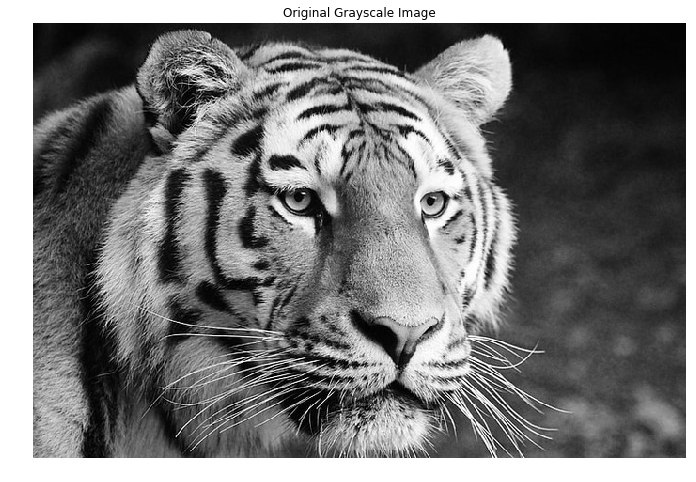

In [131]:
canvas = plt.gcf()
size = canvas.get_size_inches()
canvas.set_size_inches(size*2)

width, height = image.size
print("Image size: {}x{} pixels.".format(width,height))
plt.imshow(image_array,cmap='gray') #we just add this to get grayscale properly
plt.title('Original Grayscale Image')
plt.axis('off');  # This turns off the axis labels and ticks

In [132]:
image_array = image_array.reshape(-1)  # Reshape the image array to a 1D array. The '-1' argument indicates that the new shape should be inferred based on the original size of the array.
print("new shape:", image_array.shape)  # Print the new shape of the array to confirm it has been flattened to a 1D array

new shape: (321785,)


The array can be used like any other NumPy array. We can write some test data to the array. Later the data will be transferred by the DMA to the FIFO. 

In [133]:
for i in range(data_size):
    input_buffer[i] = image_array[i].astype(np.uint32)

Let's check the contents of the array. The data in the following cell will be sent from PS (DDR memory) to PL (streaming FIFO).

### Print first few values of buffer 

In [134]:
for i in range(10):
    print(hex(input_buffer[i]))

0x8
0x8
0x8
0x8
0x9
0xb
0xc
0xd
0x10
0xf


Now we are ready to carry out DMA transfer from a memory block in DDR to FIFO.

In [135]:
dma_send.sendchannel.transfer(input_buffer)

## Writing into the DMA
Let's read the data back from filter, and write to MM memory. The steps are similar.

We will prepare an empty array before reading data back from FIFO.

### Print first few values of  output buffer 

In [136]:
output_buffer = allocate(shape=(data_size,), dtype=np.uint32)

for i in range(10):
    print('0x' + format(output_buffer[i], '02x'))

0x00
0x00
0x00
0x00
0x00
0x00
0x00
0x00
0x00
0x00


In [137]:
dma_recv.recvchannel.transfer(output_buffer)

The next cell will print out the data received from PL (streaming FIFO) to PS (DDR memory). This should be the same as the data we sent previously.

### Print first few values of output buffer 

In [138]:
for i in range(10):
    print('0x' + format(output_buffer[i], '02x'))

0x00
0x00
0x00
0x00
0x09
0x09
0x09
0x09
0x09
0x09


Verify that the arrays are equal

In [139]:
print("Array are equal: {}".format(np.array_equal(input_buffer, output_buffer)))

Array are equal: False


original shape: (463, 695)
Cropped shape: (460, 684)


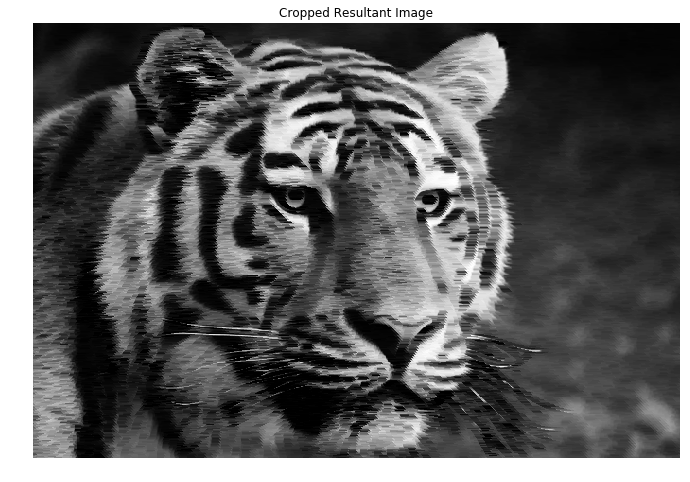

In [141]:
canvas = plt.gcf()
size = canvas.get_size_inches()
canvas.set_size_inches(size*2)
image_array1 = image_array
for i in range(data_size):  
    image_array[i] = output_buffer[i].astype(np.uint32) #now we copy the contents of output buffer in image array
image_array = image_array.reshape(463,695) #reshape it to original 

print("original shape:",image_array.shape)
 

cropped_image_array = image_array[3:, 11:]

# Print the new shape
print("Cropped shape:", cropped_image_array.shape)

# Display the cropped image
plt.imshow(cropped_image_array, cmap='gray')
plt.title('Cropped Resultant Image')
plt.axis('off')  # Turns off the axis labels and ticks
plt.show()

## Compare the hardware and Software images

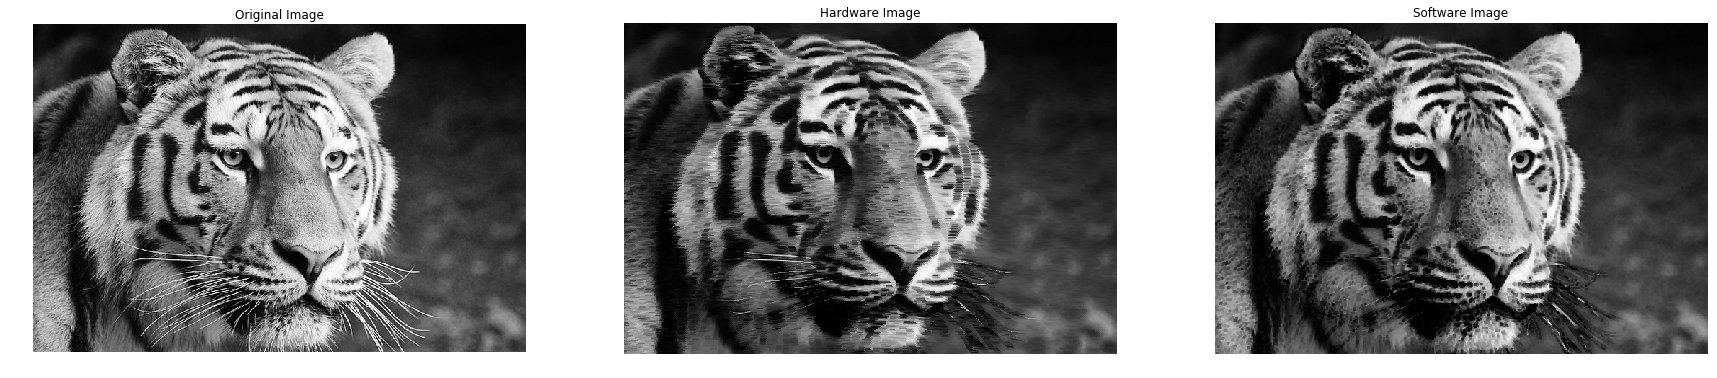

In [142]:
# Create a figure to hold the subplots
plt.figure(figsize=(30, 10))  # Adjust the size as needed to accommodate three subplots

# First subplot for the original image
plt.subplot(1, 3, 1)  # 1 row, 3 columns, first subplot
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')  # This turns off the axis labels and ticks

# Second subplot for the first image (cropped)
plt.subplot(1, 3, 2)  # 1 row, 3 columns, second subplot
plt.imshow(cropped_image_array, cmap='gray')
plt.title('Hardware Image')
plt.axis('off')  # This turns off the axis labels and ticks

# Third subplot for the second image (cropped and eroded)
plt.subplot(1, 3, 3)  # 1 row, 3 columns, third subplot
plt.imshow(cropped_eroded_img, cmap='gray')
plt.title('Software Image')
plt.axis('off')  # This turns off the axis labels and ticks

# Display the plot
plt.show()

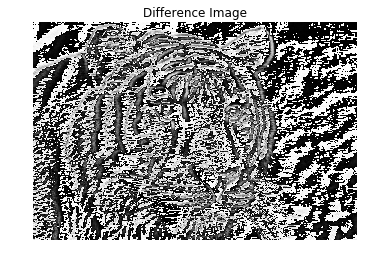

In [143]:
difference_image = np.abs(cropped_eroded_img - cropped_image_array) #computes the absolute difference pixel by pixel.
# Display the result
plt.imshow(difference_image, cmap='gray')
plt.title('Difference Image')
plt.axis('off')  # Hide axes ticks
plt.show()



## Free all the memory buffers
We free the memory buffers to avoid memory leaks!

In [144]:
del input_buffer, output_buffer